# Análisis Dinámico y Configuracional del Ownership Landscape (OL) en las Cinco Grandes Ligas Europeas (2019-2024)

## 1. Introducción y Marco Metodológico

El concepto de **Ownership Landscape (OL)** (Paisaje de Propiedad) propone entender la estructura de propiedad de una liga no como la mera suma de propietarios aislados, sino como una **configuración colectiva de mercado con dinámicas y propiedades emergentes propias** (Fiss, 2007). 

En el fútbol europeo contemporáneo coexisten modelos tradicionales arraigados en el control social (clubes de socios), modelos privados uniclub, consorcios transnacionales, firmas de capital riesgo, fondos de inversión institucional y vehículos soberanos con vínculos estatales. 

Este estudio analiza la evolución longitudinal de estos paisajes combinando dos fuentes fundamentales de variación temporal:
1. **La rotación deportiva**: El impacto de los ascensos y descensos anuales entre divisiones sobre la muestra activa de Primera División.
2. **Las transacciones corporativas longitudinales**: El cambio dinámico de dueño y modelo de control dentro de los propios clubes a lo largo del tiempo (fusiones, adquisiciones, tomas de control por fondos y absorción en redes multipropiedad).

---

### Regla de Corte Temporal para la Asignación de Temporadas
Para modelar fielmente la disponibilidad de capital y la planificación del ciclo competitivo anual, se establece como **hito temporal de corte el cierre de la ventana de transferencias de verano (1 de septiembre)** de cada año:
* Toda adquisición, toma de control o fusión formalmente cerrada (**`Fecha de cierre`**) antes o el 1 de septiembre de un año $Y$ se imputa a la temporada que inicia ese verano ($Y$/$Y+1$).
* Toda operación cerrada con posterioridad al 1 de septiembre (otoño, invierno o mitad de campaña) mantiene el modelo previo durante esa temporada y surte efecto formal a partir de la siguiente temporada ($Y+1$/$Y+2$).

---

### Preguntas de Investigación (RQs):
* **RQ1**: ¿Cómo se operacionaliza cuantitativamente el Ownership Landscape a nivel macro a través de proporciones composicionales, diversidad (Entropía de Shannon), concentración (HHI) y multipropiedad (MCO)?
* **RQ2**: ¿Cómo difieren los landscapes de propiedad entre las cinco grandes ligas europeas (Bundesliga, LaLiga, Ligue 1, Premier League y Serie A) y cómo han evolucionado longitudinalmente entre las temporadas 2019-2020 y 2024-2025?


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial import procrustes
from scipy.stats import spearmanr

# Visual configuration for academic publications
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.titlesize'] = 15
warnings.filterwarnings('ignore')

# Official color palette by ownership model
MODEL_COLORS = {
    'member-owned': '#2ca02c',       # Forest Green (Democratic / Members)
    'domestic private': '#1f77b4',   # Institutional Blue (Domestic Private)
    'foreign private': '#ff7f0e',    # Orange (Foreign Private)
    'investment fund': '#9467bd',    # Purple (Investment Funds)
    'hybrid': '#8c564b',             # Brown (Hybrid / Mixed)
    'corporate-MCO': '#d62728',      # Red (Multi-Club Ownership)
    'state-linked': '#e377c2',       # Pink / Sovereign (State-linked)
    'unknown': '#7f7f7f'             # Neutral Grey (Unresolved / Noise)
}

# League color palette
LEAGUE_COLORS = {
    'Bundesliga': '#000000',
    'LaLiga': '#ee1c25',
    'Ligue 1': '#091c3e',
    'Premier League': '#38003c',
    'Serie A': '#008fd7'
}

print("Scientific environment and English plotting configuration loaded successfully.")


Scientific environment and English plotting configuration loaded successfully.


## 2. Carga del Panel de Propiedad Dinámica y Auditoría Longitudinal (2019-2024)

Cargamos el dataset micro que integra la participación activa de los clubes en Primera División junto con su clasificación de propiedad exacta y dinámica en cada temporada.


In [2]:
# Cargar el dataset dinámico club-temporada
df_clubs = pd.read_csv('../data/dynamic_club_season_ownership.csv')

print(f"Total observaciones club-temporada activas: {len(df_clubs)}")
print(f"Total clubes únicos analizados: {df_clubs['club_id'].nunique()}")
print(f"Temporadas analizadas: {sorted(df_clubs['season'].unique())}")
print(f"Ligas incluidas: {df_clubs['league'].unique().tolist()}")

# Vista previa de observaciones
df_clubs[['club_name', 'league', 'season', 'ownership_model', 'ultimate_owner', 'mco', 'state_link']].head(10)


Total observaciones club-temporada activas: 584
Total clubes únicos analizados: 137
Temporadas analizadas: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Ligas incluidas: ['Bundesliga', 'LaLiga', 'Ligue 1', 'Premier League', 'Serie A']


,club_name,league,season,ownership_model,ultimate_owner,mco,state_link
0,FC Schalke 04,Bundesliga,2019,member-owned,Club members / registered association,0,0
1,RasenBallsport Leipzig,Bundesliga,2019,corporate-MCO,Red Bull GmbH / Red Bull-controlled associatio...,1,0
2,FC Bayern München,Bundesliga,2019,hybrid,"FC Bayern München e.V.; Adidas, Allianz and Au...",0,0
3,Borussia Dortmund,Bundesliga,2019,hybrid,Public shareholders with Borussia Dortmund e.V...,0,0
4,Eintracht Frankfurt Fußball AG,Bundesliga,2019,member-owned,Club members / registered association,0,0
5,Sportverein Werder Bremen von 1899,Bundesliga,2019,member-owned,Club members / registered association,0,0
6,Hertha BSC,Bundesliga,2019,unknown,unknown,0,0
7,SC Paderborn 07,Bundesliga,2019,member-owned,Club members / registered association,0,0
8,1. Fußball-Club Köln,Bundesliga,2019,member-owned,Club members / registered association,0,0
9,Verein für Leibesübungen Wolfsburg,Bundesliga,2019,state-linked,Volkswagen AG,0,1


## 3. Operacionalización Cuantitativa del Ownership Landscape (RQ1)

A partir de la distribución de clubes en cada liga-temporada, calculamos las métricas macro-configuracionales del Ownership Landscape:

1. **Proporciones Composicionales ($p_i$)**: 
   $$p_{i,l,t} = \frac{n_{i,l,t}}{N_{l,t}} \quad \text{con} \quad \sum_{i=1}^K p_{i,l,t} = 1.0$$
2. **Entropía de Shannon ($H$)**: Mide la diversidad, dispersión y grado de equilibrio del landscape:
   $$H_{l,t} = - \sum_{i=1}^K p_{i,l,t} \ln(p_{i,l,t})$$
3. **Índice Herfindahl-Hirschman ($HHI$)**: Mide el grado de concentración o dominancia de modelos:
   $$HHI_{l,t} = \sum_{i=1}^K p_{i,l,t}^2$$
4. **Tasa de Multipropiedad ($MCO\ Rate$)**: Proporción de clubes integrados en redes multipropiedad transnacionales.
5. **Tasa de Vínculo Estatal ($State\ Link\ Rate$)**: Proporción de clubes con vínculos geopolíticos soberanos.


In [3]:
# Cargar la matriz agregada liga-temporada
df_ol = pd.read_csv('../data/dynamic_ownership_landscape.csv')

models = [
    'member-owned', 'domestic private', 'foreign private', 
    'investment fund', 'hybrid', 'corporate-MCO', 
    'state-linked', 'unknown'
]

print(f"Matriz de Ownership Landscape: {df_ol.shape[0]} observaciones (5 ligas x 6 temporadas)")
df_ol[['league', 'season', 'n_clubs', 'entropy', 'hhi', 'mco_rate', 'state_link_rate']].head(10)


Matriz de Ownership Landscape: 30 observaciones (5 ligas x 6 temporadas)


,league,season,n_clubs,entropy,hhi,mco_rate,state_link_rate
0,Bundesliga,2019,18,1.270959,0.407407,0.055556,0.055556
1,Bundesliga,2020,18,1.270959,0.407407,0.055556,0.055556
2,Bundesliga,2021,18,1.270959,0.407407,0.055556,0.055556
3,Bundesliga,2022,18,1.270959,0.407407,0.055556,0.055556
4,Bundesliga,2023,18,1.079735,0.475309,0.055556,0.055556
5,Bundesliga,2024,18,1.050665,0.481481,0.055556,0.055556
6,LaLiga,2019,20,1.636496,0.210000,0.200000,0.000000
7,LaLiga,2020,20,1.626428,0.215000,0.150000,0.000000
8,LaLiga,2021,20,1.636496,0.210000,0.200000,0.000000
9,LaLiga,2022,20,1.679648,0.200000,0.150000,0.100000


## 4. Análisis Descriptivo y Comparativa de Perfiles por Liga (Snapshot 2024)

Comparamos la foto inicial de la muestra (2019) con el cierre del estudio (2024) para identificar las transformaciones estructurales de cada liga.


In [4]:
# Tabla comparativa 2019 vs 2024
summary_table = []
for league in sorted(df_ol['league'].unique()):
    row_19 = df_ol[(df_ol['league'] == league) & (df_ol['season'] == 2019)].iloc[0]
    row_24 = df_ol[(df_ol['league'] == league) & (df_ol['season'] == 2024)].iloc[0]
    
    # Encontrar modelo dominante en 2024
    props_24 = {m: row_24[f'prop_{m}'] for m in models}
    dom_mod = max(props_24, key=props_24.get)
    dom_pct = props_24[dom_mod] * 100
    
    summary_table.append({
        'Liga': league,
        'Clubes': f"{row_19['n_clubs']} -> {row_24['n_clubs']}",
        'Entropía (2019 -> 2024)': f"{row_19['entropy']:.3f} -> {row_24['entropy']:.3f}",
        'HHI (2019 -> 2024)': f"{row_19['hhi']:.3f} -> {row_24['hhi']:.3f}",
        'MCO Rate (2019 -> 2024)': f"{row_19['mco_rate']*100:.1f}% -> {row_24['mco_rate']*100:.1f}%",
        'State Link (2019 -> 2024)': f"{row_19['state_link_rate']*100:.1f}% -> {row_24['state_link_rate']*100:.1f}%",
        'Modelo Dominante 2024': f"{dom_mod} ({dom_pct:.1f}%)"
    })

pd.DataFrame(summary_table)


,Liga,Clubes,Entropía (2019 -> 2024),HHI (2019 -> 2024),MCO Rate (2019 -> 2024),State Link (2019 -> 2024),Modelo Dominante 2024
0,Bundesliga,18 -> 18,1.271 -> 1.051,0.407 -> 0.481,5.6% -> 5.6%,5.6% -> 5.6%,member-owned (66.7%)
1,LaLiga,20 -> 20,1.636 -> 1.805,0.210 -> 0.180,20.0% -> 25.0%,0.0% -> 5.0%,domestic private (25.0%)
2,Ligue 1,20 -> 18,1.164 -> 1.426,0.455 -> 0.272,10.0% -> 27.8%,5.0% -> 5.6%,domestic private (38.9%)
3,Premier League,20 -> 20,1.483 -> 1.752,0.245 -> 0.180,50.0% -> 60.0%,5.0% -> 10.0%,corporate-MCO (25.0%)
4,Serie A,20 -> 20,0.926 -> 1.331,0.490 -> 0.315,10.0% -> 30.0%,0.0% -> 0.0%,domestic private (45.0%)


### Visualización del Perfil de Propiedad por Liga (Temporada 2024)

El siguiente gráfico de barras apiladas ilustra la composición exacta del Ownership Landscape al cierre de la temporada 2024-2025 (etiquetado en inglés para publicación académica).


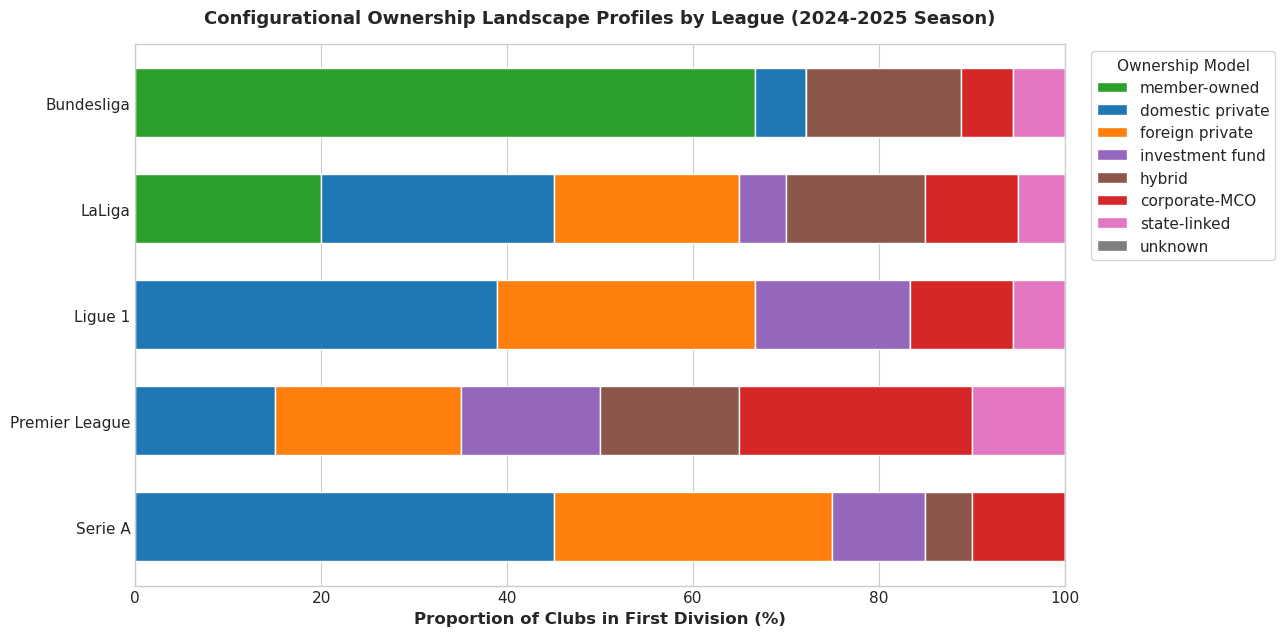

In [5]:
df_2024 = df_ol[df_ol['season'] == 2024].copy().sort_values('league', ascending=False)
prop_cols = [f'prop_{m}' for m in models]

fig, ax = plt.subplots(figsize=(13, 6.5))
left = np.zeros(len(df_2024))

for m in models:
    col = f'prop_{m}'
    values = df_2024[col].values * 100
    ax.barh(df_2024['league'], values, left=left, label=m, color=MODEL_COLORS[m], edgecolor='white', height=0.65)
    left += values

ax.set_xlabel('Proportion of Clubs in First Division (%)', fontweight='bold')
ax.set_title('Configurational Ownership Landscape Profiles by League (2024-2025 Season)', pad=15, fontweight='bold')
ax.set_xlim(0, 100)
ax.legend(title='Ownership Model', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

# Export image to images/
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/ownership_profiles_2024.png', dpi=300, bbox_inches='tight')
plt.show()


### Interpretación Detallada de los Perfiles de Propiedad (Snapshot 2024)

La distribución transversal al cierre del periodo 2024-2025 pone de manifiesto una profunda heterogeneidad institucional entre las cinco grandes ligas:

| Liga | Total Clubes | Member-owned | Domestic private | Foreign private | Investment fund | Hybrid | Corporate-MCO | State-linked | Unknown |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Bundesliga** | 18 | **66.7% (12)** | 5.6% (1) | 0.0% (0) | 0.0% (0) | **16.7% (3)** | 5.6% (1) | 5.6% (1) | 0.0% (0) |
| **LaLiga** | 20 | **20.0% (4)** | **25.0% (5)** | **20.0% (4)** | 5.0% (1) | **15.0% (3)** | 10.0% (2) | 5.0% (1) | 0.0% (0) |
| **Ligue 1** | 18 | 0.0% (0) | **38.9% (7)** | **27.8% (5)** | **16.7% (3)** | 0.0% (0) | 11.1% (2) | 5.6% (1) | 0.0% (0) |
| **Premier League** | 20 | 0.0% (0) | 15.0% (3) | **20.0% (4)** | **15.0% (3)** | 15.0% (3) | **25.0% (5)** | 10.0% (2) | 0.0% (0) |
| **Serie A** | 20 | 0.0% (0) | **45.0% (9)** | **30.0% (6)** | **10.0% (2)** | 5.0% (1) | 10.0% (2) | 0.0% (0) | 0.0% (0) |

*   **1. La Singularidad Institucional Alemana (Bundesliga)**:
    Constituye el único reducto donde el modelo asociativo sin ánimo de lucro (`member-owned`) es hegemónico (**66.7%**, 12 clubes). Sumando las estructuras mixtas (`hybrid`: Bayern München, Borussia Dortmund y Hoffenheim), el **83.4%** de la Bundesliga se rige bajo la regla del 50+1. La presencia de fondos de inversión privados es del **0.0%**, blindando la competición frente a la especulación externa.
*   **2. El Epicentro de la Globalización y la Multipropiedad (Premier League)**:
    Presenta la menor presencia de control doméstico tradicional del continente (solo un **15.0%** en propiedad privada nacional: Tottenham, Brighton, Brentford). El **70.0%** de la liga está en manos de capital extranjero o vehículos institucionales (`corporate-MCO`: 25%, `foreign private`: 20%, `investment fund`: 15%, `state-linked`: 10%). La tasa global de multipropiedad alcanza un récord europeo del **60.0%** (12 de 20 clubes).
*   **3. El Mosaico Híbrido Español (LaLiga)**:
    Es el entorno más equilibrado y diverso de Europa, donde conviven cuatro bloques significativos: el modelo democrático de socios (**20.0%**: Real Madrid, FC Barcelona, Athletic Club, CA Osasuna), la propiedad privada nacional (**25.0%**), la inversión extranjera (**20.0%**) y estructuras híbridas (**15.0%**), alcanzando la mayor Entropía de Shannon del continente ($H = 1.805$).
*   **4. La Penetración de Fondos en Italia (Serie A) y Francia (Ligue 1)**:
    Ambas ligas carecen por completo de clubes de socios ($0.0\%$). En Italia, aunque el empresariado local conserva el 45.0%, el capital institucional extranjero controla ya el **50.0%** de la liga (Milan, Inter, Roma, Fiorentina, Atalanta, Genoa, Como, Parma, Venezia, Verona). En Francia, los fondos y redes internacionales alcanzan el **55.6%** de la Ligue 1 (PSG, Lyon, Nice, Strasbourg, Toulouse, Lille, Rennes, Monaco).


## 5. Evolución Temporal de Diversidad, Concentración y Multipropiedad (2019-2024 - RQ2)

Analizamos las trayectorias longitudinales de las tres variables configuracionales clave a lo largo de las 6 temporadas.


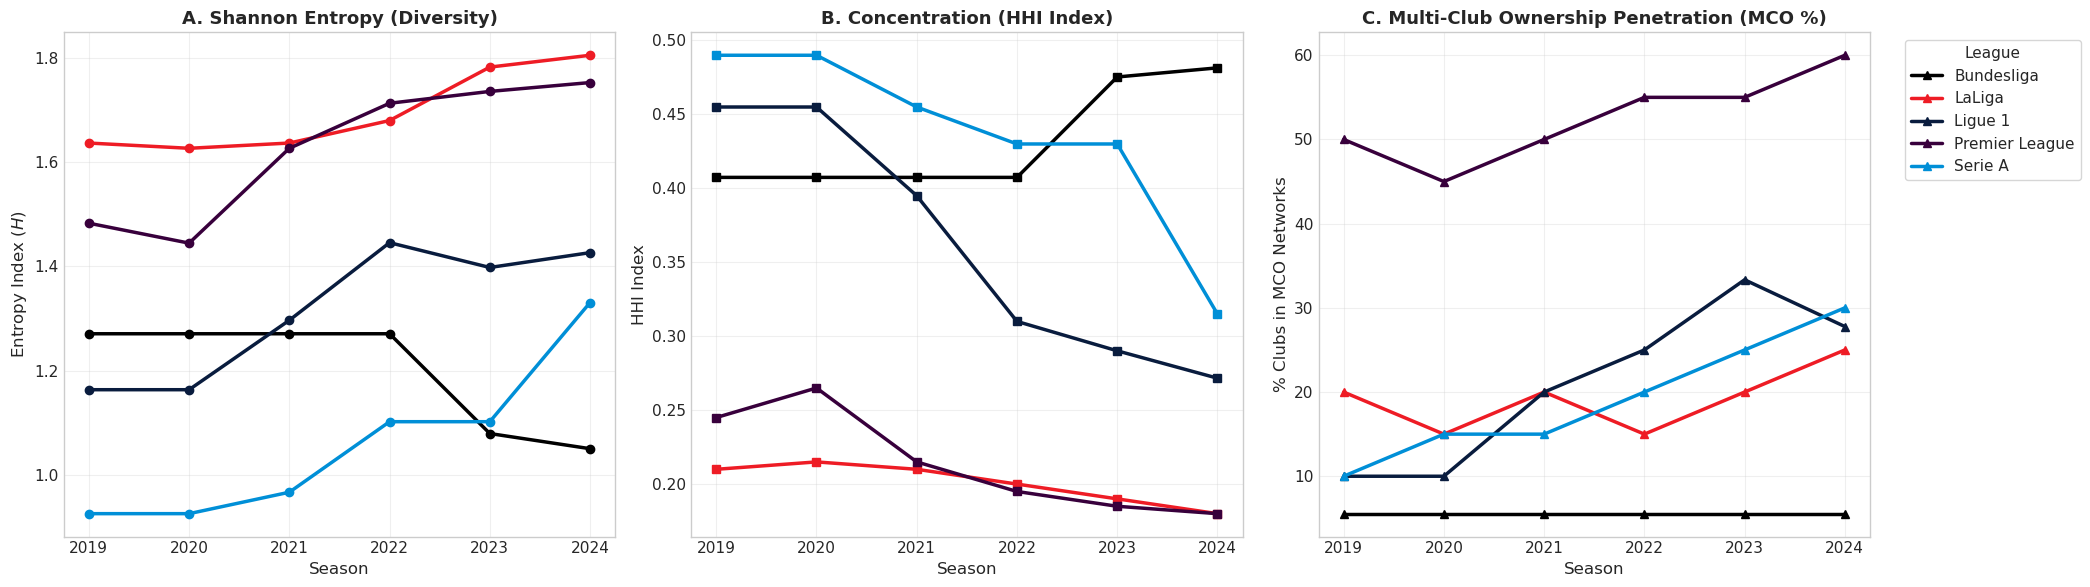

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: Shannon Entropy (Diversity)
for league, color in LEAGUE_COLORS.items():
    data = df_ol[df_ol['league'] == league]
    axes[0].plot(data['season'], data['entropy'], marker='o', linewidth=2.5, label=league, color=color)
axes[0].set_title('A. Shannon Entropy (Diversity)', fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Entropy Index ($H$)')
axes[0].set_xticks(range(2019, 2025))
axes[0].grid(True, alpha=0.3)

# Panel 2: Herfindahl-Hirschman Index (Concentration)
for league, color in LEAGUE_COLORS.items():
    data = df_ol[df_ol['league'] == league]
    axes[1].plot(data['season'], data['hhi'], marker='s', linewidth=2.5, label=league, color=color)
axes[1].set_title('B. Concentration (HHI Index)', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('HHI Index')
axes[1].set_xticks(range(2019, 2025))
axes[1].grid(True, alpha=0.3)

# Panel 3: Multi-Club Ownership Rate (MCO %)
for league, color in LEAGUE_COLORS.items():
    data = df_ol[df_ol['league'] == league]
    axes[2].plot(data['season'], data['mco_rate'] * 100, marker='^', linewidth=2.5, label=league, color=color)
axes[2].set_title('C. Multi-Club Ownership Penetration (MCO %)', fontweight='bold')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('% Clubs in MCO Networks')
axes[2].set_xticks(range(2019, 2025))
axes[2].grid(True, alpha=0.3)

axes[2].legend(title='League', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()

# Export image to images/
plt.savefig('../images/temporal_indices.png', dpi=300, bbox_inches='tight')
plt.show()


### Interpretación Detallada de la Dinámica Longitudinal

Las series temporales reflejan tres patrones fundamentales de evolución estructural:

#### A. Entropía de Shannon ($H$ - Diversidad)
| Temporada | Bundesliga | LaLiga | Ligue 1 | Premier League | Serie A |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **2019** | 1.271 | 1.636 | 1.164 | 1.483 | 0.926 |
| **2020** | 1.271 | 1.626 | 1.164 | 1.445 | 0.926 |
| **2021** | 1.271 | 1.636 | 1.297 | 1.626 | 0.967 |
| **2022** | 1.271 | 1.680 | 1.446 | 1.713 | 1.102 |
| **2023** | 1.080 | 1.782 | 1.398 | 1.735 | 1.102 |
| **2024** | **1.051** | **1.805** | **1.426** | **1.752** | **1.331** |

#### B. Índice Herfindahl-Hirschman ($HHI$ - Concentración)
| Temporada | Bundesliga | LaLiga | Ligue 1 | Premier League | Serie A |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **2019** | 0.407 | 0.210 | 0.455 | 0.245 | 0.490 |
| **2020** | 0.407 | 0.215 | 0.455 | 0.265 | 0.490 |
| **2021** | 0.407 | 0.210 | 0.395 | 0.215 | 0.455 |
| **2022** | 0.407 | 0.200 | 0.310 | 0.195 | 0.430 |
| **2023** | 0.475 | 0.190 | 0.290 | 0.185 | 0.430 |
| **2024** | **0.481** | **0.180** | **0.272** | **0.180** | **0.315** |

#### C. Tasa de Multipropiedad ($MCO\ \%$)
| Temporada | Bundesliga | LaLiga | Ligue 1 | Premier League | Serie A |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **2019** | 5.6% | 20.0% | 10.0% | 50.0% | 10.0% |
| **2020** | 5.6% | 15.0% | 10.0% | 45.0% | 15.0% |
| **2021** | 5.6% | 20.0% | 20.0% | 50.0% | 15.0% |
| **2022** | 5.6% | 15.0% | 25.0% | 55.0% | 20.0% |
| **2023** | 5.6% | 20.0% | 33.3% | 55.0% | 25.0% |
| **2024** | **5.6%** | **25.0%** | **27.8%** | **60.0%** | **30.0%** |

*   **1. La Ley del Espejo Matemático**: Los paneles de Entropía y HHI reflejan curvas perfectamente invertidas. La Bundesliga es la **única liga donde la concentración sube** ($HHI$ de $0.407$ a $0.481$) y la diversidad disminuye ($H$ de $1.271$ a $1.051$) tras la restitución del 50+1 en el Hoffenheim en noviembre de 2023, consolidando la dominancia del bloque de socios.
*   **2. La Desconcentración Histórica de Serie A y Ligue 1**: En 2019, la Serie A ($HHI = 0.490$) y la Ligue 1 ($HHI = 0.455$) presentaban los paisajes más concentrados bajo el modelo privado doméstico tradicional. Hacia 2024, el $HHI$ de la Ligue 1 se desploma un **$-40.2\%$** (hasta $0.272$) y el de la Serie A un **$-35.7\%$** (hasta $0.315$).
*   **3. La Revolución de la Multipropiedad (MCO)**: La penetración de redes multi-club se acelera en cuatro de las cinco ligas:
    *   La **Premier League** pasa del **$50.0\%$ al $60.0\%$**.
    *   La **Serie A** se **triplica** (del **$10.0\%$ al $30.0\%$**).
    *   La **Ligue 1** casi se **triplica** (del **$10.0\%$ al $27.8\%$**).
    *   **LaLiga** crece del **$20.0\%$ al $25.0\%$**.
    *   La **Bundesliga** permanece fija en el **$5.6\%$** (RB Leipzig).


## 6. Trayectorias Configuracionales del OL: Análisis de Componentes Principales (PCA)

Para capturar la estructura multidimensional del Ownership Landscape sin colapsarla en un único índice escalar, aplicamos un **Análisis de Componentes Principales (PCA)** sobre las proporciones de los 8 modelos de propiedad estandarizadas.

---

### 6.1. Cargas de los Componentes Principales (Loadings)


In [7]:
# Estandarización y PCA
X = df_ol[prop_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df_ol['PC1'] = coords[:, 0]
df_ol['PC2'] = coords[:, 1]

# Varianza explicada
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
var_total = var_pc1 + var_pc2

print(f"Varianza explicada PC1: {var_pc1:.2f}%")
print(f"Varianza explicada PC2: {var_pc2:.2f}%")
print(f"Varianza acumulada (PC1 + PC2): {var_total:.2f}%")

# Tabla de Cargas (Loadings)
loadings = pd.DataFrame(
    pca.components_.T, 
    index=[m.replace('prop_', '') for m in prop_cols], 
    columns=[f'PC1 ({var_pc1:.1f}%)', f'PC2 ({var_pc2:.1f}%)']
)
loadings


Varianza explicada PC1: 37.25%
Varianza explicada PC2: 28.77%
Varianza acumulada (PC1 + PC2): 66.02%


,PC1 (37.3%),PC2 (28.8%)
member-owned,0.557515,0.020789
domestic private,-0.357011,-0.500208
foreign private,-0.480034,0.193259
investment fund,-0.391259,0.004123
hybrid,0.191587,0.528544
corporate-MCO,-0.199024,0.490796
state-linked,0.075614,0.225458
unknown,0.310114,-0.375397


#### Interpretación de las Dimensiones:
*   **Componente Principal 1 (PC1 - Eje de Gobernanza Democrática vs. Financiarización/Privatización - $37.25\%$ varianza)**: 
    * *Cargas positivas*: `member-owned` ($+0.558$) y `unknown` ($+0.310$).
    * *Cargas negativas*: `foreign private` ($-0.480$), `investment fund` ($-0.391$) y `domestic private` ($-0.357$).
    * *Significado*: Separa los entornos basados en el control social democrático y la tradición comunitaria (derecha) de los paisajes basados en la inversión de capital privado, corporativo y financiero (izquierda).
*   **Componente Principal 2 (PC2 - Eje de Estructuras Transnacionales e Híbridas vs. Privatización Uniclub Doméstica - $28.77\%$ varianza)**:
    * *Cargas positivas*: `hybrid` ($+0.529$), `corporate-MCO` ($+0.491$) y `state-linked` ($+0.225$).
    * *Cargas negativas*: `domestic private` ($-0.500$) y `unknown` ($-0.375$).
    * *Significado*: Separa las ligas que albergan estructuras corporativas supra-club transnacionales y modelos híbridos (arriba) de aquellas basadas en clubes comerciales individuales tradicionales (abajo).


---

### 6.2. Definición de los Cuadrantes del Espacio Configuracional

La intersección de los ejes neutros ($PC1=0$ y $PC2=0$) define cuatro cuadrantes analíticos:

*   **Cuadrante I (Superior Derecho: PC1 > 0, PC2 > 0) - Modelo Democrático con Estructuras Híbridas**: Entornos que combinan un fuerte control social de socios con fórmulas corporativas híbridas y marcas globales (ej. Bundesliga moderna y LaLiga híbrida).
*   **Cuadrante II (Superior Izquierdo: PC1 < 0, PC2 > 0) - Financiarización Transnacional y Multipropiedad (MCO)**: Paisajes altamente financiarizados y comercializados con penetración masiva de redes multi-club transnacionales o influencia geopolítica soberana (ej. Premier League).
*   **Cuadrante III (Inferior Derecho: PC1 > 0, PC2 < 0) - Democrático Tradicional Uniclub Puro**: Modelo tradicional del fútbol continental con clubes de socios independientes y aislados de redes corporativas.
*   **Cuadrante IV (Inferior Izquierdo: PC1 < 0, PC2 < 0) - Privatización Comercial Uniclub Doméstica**: Ligas dominadas por propietarios privados locales o individuales de cartera única, sin agregación en grandes grupos multipropiedad (ej. Serie A histórica y Ligue 1 tradicional).


---

### 6.3. Espacio Configuracional del PCA y Trayectorias Longitudinales (2019-2024)

Proyectamos las 30 observaciones liga-temporada en el plano bidimensional y conectamos cronológicamente cada liga con vectores direccionales (con rotulación académica en inglés para su integración directa en el artículo científico).


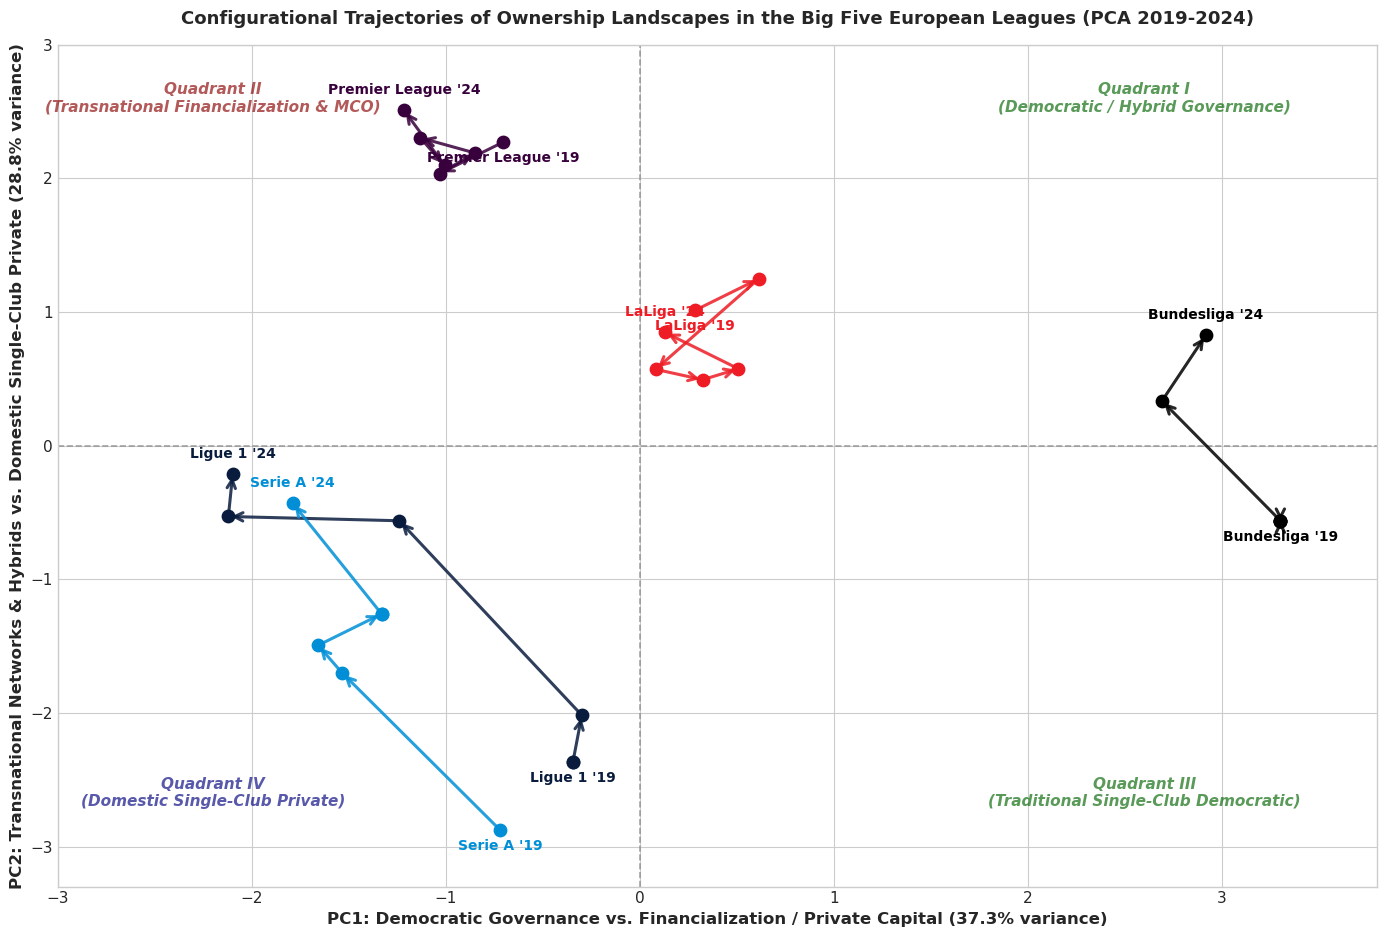

In [8]:
plt.figure(figsize=(14, 9.5))

# Draw quadrants and neutral axes
plt.axhline(0, color='grey', linestyle='--', linewidth=1.2, alpha=0.7)
plt.axvline(0, color='grey', linestyle='--', linewidth=1.2, alpha=0.7)

# Academic English quadrant annotations
plt.text(2.6, 2.5, 'Quadrant I\n(Democratic / Hybrid Governance)', fontsize=11, color='darkgreen', alpha=0.65, ha='center', style='italic', fontweight='bold')
plt.text(-2.2, 2.5, 'Quadrant II\n(Transnational Financialization & MCO)', fontsize=11, color='darkred', alpha=0.65, ha='center', style='italic', fontweight='bold')
plt.text(2.6, -2.7, 'Quadrant III\n(Traditional Single-Club Democratic)', fontsize=11, color='darkgreen', alpha=0.65, ha='center', style='italic', fontweight='bold')
plt.text(-2.2, -2.7, 'Quadrant IV\n(Domestic Single-Club Private)', fontsize=11, color='navy', alpha=0.65, ha='center', style='italic', fontweight='bold')

# Plot points and directional arrows by league
for league, color in LEAGUE_COLORS.items():
    data = df_ol[df_ol['league'] == league].sort_values('season')
    x = data['PC1'].values
    y = data['PC2'].values
    seasons = data['season'].values
    
    # Scatter points
    plt.scatter(x, y, color=color, s=80, zorder=4)
    
    # Directional trajectory arrows
    for i in range(len(x) - 1):
        plt.annotate(
            '', xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
            arrowprops=dict(arrowstyle="->", color=color, lw=2.2, alpha=0.85, mutation_scale=15)
        )
    
    # Label start (2019) and end (2024)
    plt.text(x[0], y[0] - 0.15, f"{league} '19", fontsize=10, fontweight='bold', color=color, ha='center')
    plt.text(x[-1], y[-1] + 0.12, f"{league} '24", fontsize=10, fontweight='bold', color=color, ha='center')

plt.xlabel(f'PC1: Democratic Governance vs. Financialization / Private Capital ({var_pc1:.1f}% variance)', fontweight='bold')
plt.ylabel(f'PC2: Transnational Networks & Hybrids vs. Domestic Single-Club Private ({var_pc2:.1f}% variance)', fontweight='bold')
plt.title('Configurational Trajectories of Ownership Landscapes in the Big Five European Leagues (PCA 2019-2024)', pad=15, fontweight='bold')
plt.xlim(-3.0, 3.8)
plt.ylim(-3.3, 3.0)
plt.tight_layout()

# Export image to images/
plt.savefig('../images/pca_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()


### Análisis Detallado de Trayectorias por Liga (2019-2024)

Las coordenadas anuales de las cinco ligas revelan tres trayectorias institucionales nítidas:

| Liga | 2019 (Inicio) | 2020 | 2021 | 2022 | 2023 | 2024 (Cierre) | Cuadrante Dominante |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **Bundesliga** | $(+3.302, -0.562)$ | $(+3.302, -0.562)$ | $(+3.302, -0.562)$ | $(+3.302, -0.562)$ | $(+2.692, +0.335)$ | **$(+2.917, +0.826)$** | **Cuadrante I / III (Derecha)** |
| **LaLiga** | $(+0.285, +1.013)$ | $(+0.612, +1.248)$ | $(+0.082, +0.571)$ | $(+0.324, +0.494)$ | $(+0.508, +0.575)$ | **$(+0.129, +0.848)$** | **Cuadrante I (Superior Derecho)** |
| **Premier League**| $(-0.705, +2.272)$ | $(-1.032, +2.037)$ | $(-0.850, +2.190)$ | $(-1.131, +2.304)$ | $(-1.007, +2.097)$ | **$(-1.216, +2.511)$** | **Cuadrante II (Superior Izquierdo)** |
| **Serie A** | $(-0.720, -2.878)$ | $(-1.534, -1.701)$ | $(-1.659, -1.494)$ | $(-1.331, -1.259)$ | $(-1.331, -1.259)$ | **$(-1.789, -0.431)$** | **Cuadrante IV $\to$ Ascenso vertical** |
| **Ligue 1** | $(-0.345, -2.366)$ | $(-0.345, -2.366)$ | $(-0.299, -2.018)$ | $(-1.240, -0.562)$ | $(-2.121, -0.530)$ | **$(-2.099, -0.210)$** | **Cuadrante IV $\to$ Ascenso vertical** |

*   **1. Bundesliga (El Anclaje Institucional del 50+1)**:
    Permanece aislada en el extremo derecho ($PC1 > +2.6$), inmune a la financiarización anglosajona. Su desplazamiento hacia arriba en 2023-2024 ($PC2 = -0.56 \to +0.83$) responde a la renuncia voluntaria de Dietmar Hopp a su estatus de excepción en el Hoffenheim, devolviendo la mayoría de votos al club asociativo y reforzando el modelo híbrido/socios.
*   **2. Premier League (El Polo de la Globalización MCO)**:
    Se ubica en la cúspide del Cuadrante II ($PC2 > +2.0$, $PC1 < 0$). Su vector se desplaza progresivamente hacia la izquierda y hacia arriba (terminando en $x = -1.22, y = +2.51$ en 2024), reflejando la absorción continua de clubes en redes multi-club (Chelsea a BlueCo, Bournemouth a Black Knight, Burnley a ALK Capital).
*   **3. LaLiga (El Equilibrio Híbrido)**:
    Se mantiene en el **Cuadrante I** ($PC1 \in [0.08, 0.61]$, $PC2 \in [0.49, 1.25]$). La existencia de sus 4 clubes de socios actúa como un contrapeso estructural hacia la derecha, mientras que sus acuerdos híbridos y adquisiciones selectivas en red (Girona/CFG) la sitúan en la zona superior de integración internacional.
*   **4. Serie A y Ligue 1 (La Gran Reconfiguración Hacia Arriba)**:
    En 2019, ambas ligas se situaban en la base profunda del Cuadrante IV ($y = -2.88$ y $y = -2.37$), dominadas por familias empresariales locales de cartera individual. Entre 2019 y 2024, **ambas ligas describen una espectacular trayectoria ascendente vertical** (la Serie A asciende a $y = -0.43$ y la Ligue 1 a $y = -0.21$), constatando empíricamente la colonización del sur de Europa por fondos norteamericanos y redes multipropiedad.


---

### 6.4. Validación de Robustez: PCA Composicional (CLR) y Análisis de Procrustes

Para verificar que la restricción de suma unitaria ($1.0$) de los datos composicionales y la categoría *unknown* no introducen distorsiones geométricas, aplicamos la transformación **Centered Log-Ratio (CLR)** (Pawlowsky-Glahn et al., 2015) y el test de similitud de **Procrustes**.


In [9]:
# 1. Transformación CLR (Centered Log-Ratio)
X_coda = df_ol[prop_cols].drop(columns=['prop_unknown'])
X_coda = X_coda.div(X_coda.sum(axis=1), axis=0) + 1e-5
X_coda = X_coda.div(X_coda.sum(axis=1), axis=0)

log_X = np.log(X_coda)
clr_X = log_X.sub(log_X.mean(axis=1), axis=0)
clr_scaled = scaler.fit_transform(clr_X)

pca_clr = PCA(n_components=2)
coords_clr = pca_clr.fit_transform(clr_scaled)

# 2. Correlaciones entre PCA convencional y CLR-PCA
corr_pearson = np.corrcoef(coords[:, 0], coords_clr[:, 0])[0, 1]
corr_spearman, _ = spearmanr(coords[:, 0], coords_clr[:, 0])

# 3. Test de Procrustes
_, _, disparity = procrustes(coords, coords_clr)
procrustes_sim = np.sqrt(1 - disparity)

print("=== RESULTADOS DE VALIDACIÓN Y ROBUSTEZ ===")
print(f"Correlación de Pearson en PC1 (Convencional vs. CLR): {abs(corr_pearson):.4f}")
print(f"Correlación de Spearman en PC1 (Convencional vs. CLR): {abs(corr_spearman):.4f}")
print(f"Similitud geométrica de Procrustes (R): {procrustes_sim:.4f}")
print(f"Disparidad residual de Procrustes (D): {disparity:.4f}")


=== RESULTADOS DE VALIDACIÓN Y ROBUSTEZ ===
Correlación de Pearson en PC1 (Convencional vs. CLR): 0.8737
Correlación de Spearman en PC1 (Convencional vs. CLR): 0.8031
Similitud geométrica de Procrustes (R): 0.6540
Disparidad residual de Procrustes (D): 0.5723


## 7. Discusión y Conclusiones Finales

El análisis dinámico y configuracional del **Ownership Landscape** en las cinco grandes ligas europeas (2019-2024) permite extraer tres conclusiones fundamentales:

1. **La Estructura de Propiedad es un Fenómeno Colectivo y Dinámico (RQ1)**:
   El constructo del Ownership Landscape operacionalizado a través de proporciones composicionales, Entropía de Shannon ($H$), HHI y Análisis de Componentes Principales (PCA) demuestra ser un marco analítico sumamente potente y metodológicamente robusto para tipificar los regímenes de gobernanza del fútbol europeo. La integración de 44 operaciones corporativas de cambio de control revela que las ligas no son agregados estáticos, sino ecosistemas en constante reconfiguración institucional.

2. **Divergencia entre Tres Regímenes Competitivos Europeos (RQ2)**:
   * **El Régimen Proteccionista Democrático (Alemania)**: La Bundesliga constituye un caso singular de estabilidad absoluta. La regla del 50+1 opera como un cortafuegos eficaz que preserva la gobernanza asociativa ($66.7\%$) e impide la penetración de fondos especulativos o redes multipropiedad ($5.6\%$).
   * **El Régimen Globalizado MCO (Inglaterra)**: La Premier League representa la vanguardia de la financiarización, liderando la multipropiedad transnacional ($60.0\%$) y configurando un mercado dominado por fondos de inversión y consorcios internacionales.
   * **El Régimen en Transición Financiera (Italia y Francia, con España como puente híbrido)**: La Serie A y la Ligue 1 han experimentado una profunda transformación vertical en el PCA, transitando desde paisajes de mecenazgo familiar uniclub hacia ecosistemas colonizados por firmas de inversión y consorcios globales.

3. **Implicaciones de Política Regulatoria y Gobernanza de la UEFA**:
   La rápida expansión de las redes de multipropiedad (que ya superan el $25\%$ en 4 de las 5 grandes ligas y alcanzan el $60\%$ en Inglaterra) plantea desafíos regulatorios inmediatos sobre la integridad competitiva, los traspasos intra-grupo y la multipropiedad en competiciones UEFA, exigiendo un marco de supervisión adaptado a la realidad de las redes corporativas transnacionales.
